# ALL Subjects Encoding Analysis (CLIP vs Brain-AE)

This notebook mirrors `Subject1EncodingAnalysis.ipynb`, but runs the analysis **across all four subjects (CSI1–CSI4)** using the **ALL4 denoising autoencoder** outputs.

Goal: compare representational structure of the learned brain embeddings vs CLIP embeddings (RSA + clustering + kNN inspection).

In [6]:
from __future__ import annotations

# --- Imports ---
import glob
import json
import os
from dataclasses import dataclass
from functools import lru_cache
from pathlib import Path
from typing import Any

import numpy as np
import matplotlib.pyplot as plt

In [7]:
# --- Configuration (edit these if needed) ---
REPO_ROOT = Path.cwd()
PROCESSED_DIR = REPO_ROOT / 'processed_data'
SUBJECTS = ['CSI1', 'CSI2', 'CSI3', 'CSI4']
VARIANT = 'schaefer1014'
CLIP_JSON_PATH = REPO_ROOT / 'ClipEmbeddings.json'
STIMULI_DIR = '/media/hdd/BOLD5000/BOLD5000_Stimuli/Scene_Stimuli/Presented_Stimuli'

# Expecting per-subject exports created with the ALL4 denoising model.
# If you used different filenames, change the pattern below.
AUTO_NPZ_NAME_TEMPLATE = '{subject}_autoEmbeddings_ALL4denoise.npz'

print('repo:', REPO_ROOT)
print('subjects:', SUBJECTS)
print('variant:', VARIANT)
print('clip json:', CLIP_JSON_PATH)
print('stimuli dir:', STIMULI_DIR)
for s in SUBJECTS:
    p = PROCESSED_DIR / s / AUTO_NPZ_NAME_TEMPLATE.format(subject=s)
    print('auto npz:', p, 'exists:', p.exists())

repo: /home/mariop/Documents/Programming/bold5000-gan
subjects: ['CSI1', 'CSI2', 'CSI3', 'CSI4']
variant: schaefer1014
clip json: /home/mariop/Documents/Programming/bold5000-gan/ClipEmbeddings.json
stimuli dir: /media/hdd/BOLD5000/BOLD5000_Stimuli/Scene_Stimuli/Presented_Stimuli
auto npz: /home/mariop/Documents/Programming/bold5000-gan/processed_data/CSI1/CSI1_autoEmbeddings_ALL4denoise.npz exists: True
auto npz: /home/mariop/Documents/Programming/bold5000-gan/processed_data/CSI2/CSI2_autoEmbeddings_ALL4denoise.npz exists: True
auto npz: /home/mariop/Documents/Programming/bold5000-gan/processed_data/CSI3/CSI3_autoEmbeddings_ALL4denoise.npz exists: True
auto npz: /home/mariop/Documents/Programming/bold5000-gan/processed_data/CSI4/CSI4_autoEmbeddings_ALL4denoise.npz exists: True


In [8]:
# --- Small helpers ---
def reconstruct_raw_imagename(name: Any) -> str:
    if isinstance(name, (bytes, np.bytes_)):
        name = name.decode('utf-8', errors='replace')
    return os.path.basename(str(name))

def load_clip_lookup(path: Path) -> tuple[dict[str, np.ndarray], dict[str, list[str]]]:
    with open(path, 'r') as f:
        payload = json.load(f)
    clip_lookup: dict[str, np.ndarray] = {}
    label_lookup: dict[str, list[str]] = {}
    for it in payload.get('items', []):
        name = reconstruct_raw_imagename(it['imgname'])
        clip_lookup[name] = np.asarray(it['clip_embedding'], dtype=np.float32)
        label_lookup[name] = list(it.get('labels', []))
    return clip_lookup, label_lookup

CLIP_LOOKUP, HUMAN_LABEL_LOOKUP = load_clip_lookup(CLIP_JSON_PATH)
print('n unique images in CLIP json:', len(CLIP_LOOKUP))

n unique images in CLIP json: 4916


In [9]:
# --- Map imgname -> stimulus path ---
@lru_cache(maxsize=1)
def _build_image_map(stimuli_dir: str = STIMULI_DIR) -> dict[str, str]:
    exts = ('*.jpg', '*.jpeg', '*.JPEG', '*.png')
    paths: list[str] = []
    for ext in exts:
        paths += glob.glob(f'{stimuli_dir}/**/{ext}', recursive=True)
    return {os.path.basename(p): p for p in paths}

def resolve_raw_image_path(imgname: str) -> str | None:
    key = reconstruct_raw_imagename(imgname)
    m = _build_image_map()
    return m.get(key)

In [10]:
# --- Load per-subject auto-embeddings from the ALL4 model, stack across subjects ---
@dataclass(frozen=True)
class Row:
    subject: str
    imgname: str
    labels: list[str]
    z_brain: np.ndarray
    clip: np.ndarray
    image_path: str | None

def load_subject_rows(subject: str) -> list[Row]:
    p = PROCESSED_DIR / subject / AUTO_NPZ_NAME_TEMPLATE.format(subject=subject)
    if not p.exists():
        raise FileNotFoundError(f'Missing {p}. Export ALL4 latents first.')
    auto = np.load(p, allow_pickle=True)
    imgnames = [reconstruct_raw_imagename(x) for x in auto['imgnames'].tolist()]
    labels = auto['labels'].tolist()
    Z = np.asarray(auto['Z'], dtype=np.float32)
    rows: list[Row] = []
    for i, name in enumerate(imgnames):
        if name not in CLIP_LOOKUP:
            continue
        rows.append(Row(subject=subject, imgname=name, labels=list(labels[i]), z_brain=Z[i], clip=CLIP_LOOKUP[name], image_path=resolve_raw_image_path(name)))
    return rows

rows_all: list[Row] = []
for s in SUBJECTS:
    sr = load_subject_rows(s)
    print(s, 'rows:', len(sr))
    rows_all.extend(sr)

subjects = [r.subject for r in rows_all]
imgnames = [r.imgname for r in rows_all]
labels = [r.labels for r in rows_all]
image_paths = [r.image_path for r in rows_all]
E_brain = np.stack([r.z_brain for r in rows_all], axis=0).astype(np.float32)
E_clip = np.stack([r.clip for r in rows_all], axis=0).astype(np.float32)
print('E_brain:', E_brain.shape, 'E_clip:', E_clip.shape)
print('missing stimulus paths:', sum(p is None for p in image_paths))
print('example:', subjects[0], imgnames[0], labels[0])

CSI1 rows: 4916
CSI2 rows: 4916
CSI3 rows: 4916
CSI4 rows: 2952
CSI3 rows: 4916
CSI4 rows: 2952
E_brain: (17700, 768) E_clip: (17700, 768)
missing stimulus paths: 17700
example: CSI1 n01930112_19568.JPEG ['nematode']
E_brain: (17700, 768) E_clip: (17700, 768)
missing stimulus paths: 17700
example: CSI1 n01930112_19568.JPEG ['nematode']


## RSA: compare geometry of CLIP vs brain-AE spaces
We compute cosine RDMs and correlate the upper triangles with Spearman rho.

In [11]:
def l2_normalize(X: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    n = np.linalg.norm(X, axis=1, keepdims=True)
    return X / (n + eps)

def cosine_rdm(X: np.ndarray) -> np.ndarray:
    Xn = l2_normalize(X)
    S = Xn @ Xn.T
    return (1.0 - S).astype(np.float32)

def upper_tri(rdm: np.ndarray) -> np.ndarray:
    iu = np.triu_indices(rdm.shape[0], k=1)
    return rdm[iu]

def spearmanr_fast(a: np.ndarray, b: np.ndarray) -> float:
    # rank-transform then pearson
    ar = a.argsort().argsort().astype(np.float64)
    br = b.argsort().argsort().astype(np.float64)
    ar -= ar.mean()
    br -= br.mean()
    denom = (np.sqrt((ar**2).sum()) * np.sqrt((br**2).sum())) + 1e-12
    return float((ar @ br) / denom)

# Full RSA (can be large; optionally subsample for speed)
N = E_brain.shape[0]
SUBSAMPLE = min(3000, N)
rng = np.random.default_rng(0)
idx = np.arange(N) if SUBSAMPLE == N else rng.choice(N, size=SUBSAMPLE, replace=False)

R_brain = cosine_rdm(E_brain[idx])
R_clip = cosine_rdm(E_clip[idx])
rho = spearmanr_fast(upper_tri(R_brain), upper_tri(R_clip))
print('RSA Spearman rho (subsampled):', rho, 'n=', len(idx))

RSA Spearman rho (subsampled): 0.01876720575880315 n= 3000


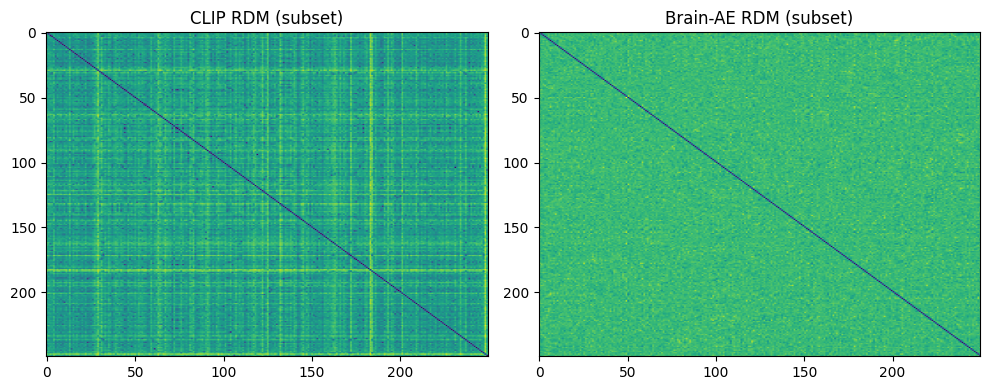

In [12]:
# Quick RDM heatmap (subset)
m = min(250, len(idx))
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].imshow(R_clip[:m, :m], aspect='auto')
axs[0].set_title('CLIP RDM (subset)')
axs[1].imshow(R_brain[:m, :m], aspect='auto')
axs[1].set_title('Brain-AE RDM (subset)')
plt.tight_layout()
plt.show()

## Clustering + label summaries
We approximate cosine clustering by KMeans on L2-normalized vectors and summarize by top labels per cluster.

In [18]:
from collections import Counter
from sklearn.cluster import KMeans

def primary_label(lbls: list[str]) -> str:
    return (lbls[0] if lbls else 'unknown')

def summarize_clusters(assign: np.ndarray, labels: list[list[str]], *, topk: int = 8):
    for k in sorted(set(assign.tolist())):
        idxk = np.where(assign == k)[0]
        c = Counter(primary_label(labels[i]) for i in idxk)
        top = c.most_common(topk)
        print(f'cluster {k:>2d}  n={len(idxk):>5d}  top:', top)

K = 20
Xc = l2_normalize(E_clip)
Xb = l2_normalize(E_brain)

kmeans_clip = KMeans(n_clusters=K, random_state=0, n_init=10).fit(Xc)
kmeans_brain = KMeans(n_clusters=K, random_state=0, n_init=10).fit(Xb)

print('CLIP clusters:')
summarize_clusters(kmeans_clip.labels_, labels)

print('Brain-AE clusters:')
summarize_clusters(kmeans_brain.labels_, labels)

CLIP clusters:
cluster  0  n=  522  top: [('banana', 65), ('person', 28), ('orange', 25), ('broccoli', 19), ('Appleorchard', 16), ('bowl', 15), ('Cornfield', 15), ('dining table', 13)]
cluster  1  n= 1282  top: [('giraffe', 275), ('zebra', 228), ('elephant', 178), ('bear', 79), ('person', 39), ('Savanna', 8), ('gazelle', 8), ('jaguar', 8)]
cluster  2  n=  764  top: [('person', 64), ('boat', 55), ('airplane', 52), ('motorcycle', 45), ('kite', 31), ('Chemicalplant', 15), ('Onboat', 15), ('Cockpit', 15)]
cluster  3  n=  684  top: [('person', 221), ('sports ball', 164), ('horse', 22), ('baseball bat', 22), ('Show Jumping', 16), ('Baseball', 13), ('tennis racket', 12), ('chair', 10)]
cluster  4  n=  769  top: [('boat', 39), ('umbrella', 18), ('Coralreef', 16), ('Cave', 16), ('Cliff', 16), ('Desertvegetation', 15), ('Forestpath', 15), ('bird', 15)]
cluster  5  n= 1204  top: [('dog', 168), ('cat', 95), ('Newfoundland', 8), ('pug', 8), ('Border_collie', 8), ('Lhasa', 8), ('Lakeland_terrier', 8

## Nearest neighbors (kNN) sanity checks
Find top-10 neighbors for a query label substring, in both CLIP and Brain-AE spaces.

In [21]:
def cosine_topk(X: np.ndarray, q: np.ndarray, k: int = 10) -> tuple[np.ndarray, np.ndarray]:
    Xn = l2_normalize(X)
    qn = q / (np.linalg.norm(q) + 1e-12)
    sims = Xn @ qn
    idx = np.argsort(-sims)[:k]
    return idx, sims[idx]

def find_index_by_label_substring(labels: list[list[str]], sub: str) -> int | None:
    sub = sub.lower()
    for i, ls in enumerate(labels):
        if any(sub in str(x).lower() for x in ls):
            return i
    return None

def show_neighbors(query_sub: str, k: int = 10):
    qi = find_index_by_label_substring(labels, query_sub)
    if qi is None:
        print('no match for', query_sub)
        return
    print('Query:', query_sub, '| row:', qi, '|', subjects[qi], imgnames[qi], '|', labels[qi])
    idxc, simc = cosine_topk(E_clip, E_clip[qi], k=k)
    idxb, simb = cosine_topk(E_brain, E_brain[qi], k=k)
    print('  CLIP neighbors:')
    for j, s0 in zip(idxc, simc):
        print('   ', f'{s0: .3f}', subjects[j], imgnames[j], primary_label(labels[j]))
    print('  Brain-AE neighbors:')
    for j, s0 in zip(idxb, simb):
        print('   ', f'{s0: .3f}', subjects[j], imgnames[j], primary_label(labels[j]))

for q in ['dog', 'plane', 'house']:
    show_neighbors(q, k=10)

Query: dog | row: 122 | CSI1 COCO_train2014_000000523272.jpg | ['dog', 'car', 'truck', 'traffic light', 'person']
  CLIP neighbors:
     1.000 CSI1 COCO_train2014_000000523272.jpg dog
     1.000 CSI2 COCO_train2014_000000523272.jpg dog
     1.000 CSI3 COCO_train2014_000000523272.jpg dog
     1.000 CSI4 COCO_train2014_000000523272.jpg dog
     0.750 CSI3 COCO_train2014_000000340734.jpg dog
     0.750 CSI2 COCO_train2014_000000340734.jpg dog
     0.750 CSI1 COCO_train2014_000000340734.jpg dog
     0.750 CSI4 COCO_train2014_000000340734.jpg dog
     0.740 CSI2 COCO_train2014_000000438751.jpg dog
     0.740 CSI4 COCO_train2014_000000438751.jpg dog
  Brain-AE neighbors:
     1.000 CSI1 COCO_train2014_000000523272.jpg dog
     0.356 CSI1 pub2.jpg Pub
     0.345 CSI1 COCO_train2014_000000150559.jpg cell phone
     0.333 CSI1 lockerroom.jpg Lockerroom
     0.333 CSI1 bar8.jpg Bar
     0.332 CSI1 n02011460_1645.JPEG bittern
     0.328 CSI1 n03877845_13042.JPEG palace
     0.327 CSI1 n01847000_1

## Summary + quick interpretation
Run the notebook, then fill in the printed metrics below (RSA rho, cluster summaries, and neighbor quality).

Expected outcomes to look for:
- RSA rho higher than Subject1-only model (if multi-subject training helped)
- Brain-AE clusters less dominated by generic categories (e.g., 'person')
- kNN neighbors in brain space more semantically coherent across subjects

In [ ]:
# Fill-in summary helper (auto-populated from current run)
summary = {
    'n_rows_total': int(E_brain.shape[0]),
    'rsa_rho_subsampled': float(rho),
    'subjects': SUBJECTS,
    'auto_npz_template': AUTO_NPZ_NAME_TEMPLATE,
}
summary